In [1]:
import pandas as pd
from sqlalchemy import create_engine
from utils.database import get_engine
import seaborn as sns
import matplotlib.pyplot as plt

engine = get_engine()

In [2]:
df = pd.read_sql(
    "SELECT * FROM vw_profit_analysis",
    engine
)


In [3]:
#Sort Data By Profit
df_abc = df.sort_values(by="profit", ascending=False)


In [4]:
#Cumulative Profit
df_abc["cum_profit"] = df_abc["profit"].cumsum()

df_abc["cum_profit_percent"] = (
    df_abc["cum_profit"] / df_abc["profit"].sum()
) * 100

In [5]:
#ABC Categorization
def abc_class(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

df_abc["ABC_Category"] = df_abc["cum_profit_percent"].apply(abc_class)

In [6]:
df_abc[["sku", "profit", "cum_profit_percent", "ABC_Category"]].head(20)

,sku,profit,cum_profit_percent,ABC_Category
2,SKU2,9397.086845,1.809224,A
38,SKU38,9337.478545,3.606972,A
67,SKU67,9288.320543,5.395255,A
88,SKU88,9268.839613,7.179787,A
51,SKU51,9152.509811,8.941923,A
31,SKU31,8982.825089,10.671389,A
99,SKU99,8935.058898,12.391658,A
52,SKU52,8815.066209,14.088826,A
32,SKU32,8774.085006,15.778103,A
18,SKU18,8739.746041,17.460769,A


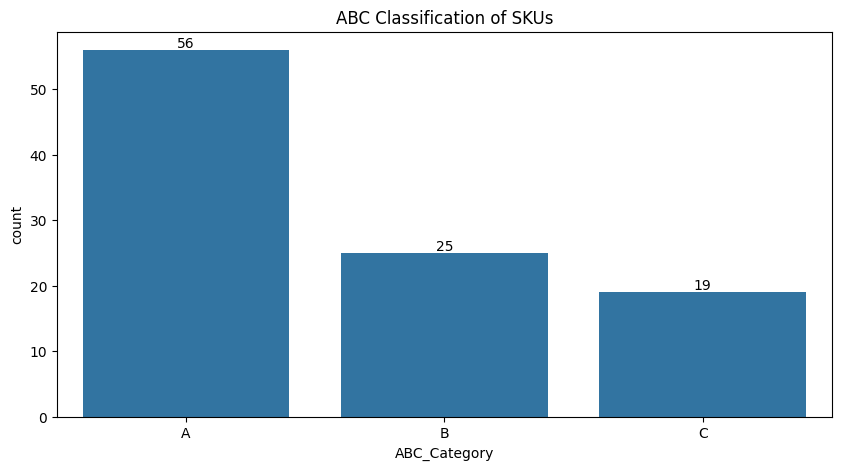

In [7]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df_abc, x="ABC_Category", order=["A","B","C"])
plt.title("ABC Classification of SKUs")
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [8]:
df_abc.groupby("ABC_Category")["profit"].sum()

ABC_Category
A    412228.810402
B     81113.664468
C     26056.281421
Name: profit, dtype: float64

## ABC Analysis – Key Insights

ABC analysis was performed on SKUs based on cumulative profit contribution.

### Profit Contribution by Category
- Category A: ~79% of total profit (412,228)
- Category B: ~16% of total profit (81,113)
- Category C: ~5% of total profit (26,056)

### SKU Distribution
- A: 52 SKUs  
- B: 25 SKUs  
- C: 19 SKUs  

### Business Interpretation
Category A products contribute the majority of profit and are the most critical for business performance. These SKUs should be prioritized in inventory planning and supply chain management.  

Category B products are moderately important and should be optimized for balanced performance.  

Category C products contribute minimal profit and can be managed with relaxed inventory policies or considered for optimization.

Although Category A contains a larger number of SKUs, it still follows the Pareto principle in terms of value contribution, where a small subset of products generates the majority of profit.